# Assuta Final Project - Step 7: Modeling, Evaluation and Explainability

This notebook is the **final modeling notebook**.

It starts from the fixed Train/Test outputs created in Step 6 and follows this order:

1. Dummy baseline
2. **Balancing-strategy screening on Train/CV only**
   - Class weighting
   - SMOTE
   - CTGAN
   - CTGAN + SMOTE
3. Lock one balancing strategy
4. Logistic Regression / Random Forest / XGBoost / CatBoost
5. Hyperparameter tuning on Train/CV only
6. Lock the final algorithm
7. Threshold tuning on out-of-fold Train predictions
8. Probability calibration on Train/CV only
9. Re-tune the threshold if calibration changes the probability scale
10. One-time final evaluation on Test
11. ROC / Precision-Recall / Calibration / Confusion Matrix figures
12. Structured-only vs Structured + NLP comparison
13. Explainability: coefficients / permutation importance / SHAP
14. Error analysis and subgroup analysis
15. Save all tables, figures and selected-model metadata

### Important methodological rule
The **Test set is not used to choose the balancing strategy, model, hyperparameters, calibration method or threshold**.
All selection decisions are made using Train / Cross-Validation only.


## Step 0 - Configuration

Edit only paths and project-level decisions.

The balancing screen is intentionally lighter than the final model tuning:
it uses a small number of representative models and fewer CV folds to choose the most promising balancing strategy first.

`CLINICAL_RECALL_TARGET` is `None` by default. If no clinical recall target is approved, the threshold is selected by maximum F2 on out-of-fold Train predictions.


In [2]:
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
import json
import math
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone, BaseEstimator, ClassifierMixin
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
    RandomizedSearchCV,
)
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
    brier_score_loss,
    log_loss,
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.inspection import permutation_importance

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 300)

RANDOM_STATE = 42
CV_FOLDS = 5
N_JOBS = -1

# ------------------------------------------------------------------
# Step 6 outputs
# ------------------------------------------------------------------
STEP6_DIR = Path(r"H:\27 project\pre_modeling\step6_outputs")

X_TRAIN_PATH = STEP6_DIR / "X_train.csv"
X_TEST_PATH = STEP6_DIR / "X_test.csv"
Y_TRAIN_PATH = STEP6_DIR / "y_train.csv"
Y_TEST_PATH = STEP6_DIR / "y_test.csv"
TRAIN_IDS_PATH = STEP6_DIR / "train_case_ids.csv"
TEST_IDS_PATH = STEP6_DIR / "test_case_ids.csv"

# Step 5 final table is used only for subgroup/error context.
STEP5_FINAL_FEATURE_TABLE_PATH = Path(
    r"H:\27 project\feature_engineering\fe_outputs\assuta_final_feature_table.csv"
)

OUTPUT_DIR = Path(r"H:\27 project\models\step7_outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "model_metadata"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COL = "target_binary"
CASE_ID_COL = "case_number"

# ------------------------------------------------------------------
# Runtime controls
# ------------------------------------------------------------------
RUN_HYPERPARAMETER_TUNING = True
N_RANDOM_SEARCH_ITER = 20

RUN_BALANCING_SCREEN = True
BALANCE_SCREEN_CV_FOLDS = 3

# Efficient first-stage comparison: choose the balancing strategy before full tuning.
BALANCING_STRATEGIES = ["class_weight", "smote", "ctgan", "ctgan_smote"]

# CTGAN is deliberately lighter in the screening stage.
CTGAN_EPOCHS = 100

# 🔴 TODO (Tal/Hodaya): CONFIRM. Previously 1.0 (full 1:1 balance) - relaxed to
# match the same principle already applied in Step 6's prototype averaging: full
# balance was explicitly rejected there as making the data "an illusion" (see
# MAJORITY_AVERAGING_TARGET_LOCAL_RATIO / PROTOTYPE_GROUP_SIZE discussion). CTGAN
# generating synthetic minority cases up to a full 1:1 target is the same kind of
# over-correction, just from the other direction (inventing positives instead of
# collapsing negatives). 0.3 means CTGAN tops the minority class up to ~30% of the
# majority count - adjust based on what the balancing screen (Step 7) shows.
CTGAN_TARGET_RATIO = 0.3
CTGAN_SMOTE_INTERMEDIATE_RATIO = 0.15  # kept proportionally lower, same reasoning

RUN_CALIBRATION = True
RUN_SHAP = True
RUN_SUBGROUP_ANALYSIS = True
RUN_NLP_COMPARISON = True
RUN_24H_48H_SENSITIVITY = False

# Clinical threshold - checked in this priority order:
#   1. CLINICAL_NNS_TARGET  (Dr. Manor's actual stated criterion)
#   2. CLINICAL_RECALL_TARGET (if a recall target is separately approved instead)
#   3. F2-optimal fallback (no clinical criterion configured)
#
# Dr. Manor (project meeting): "willing to screen ~20 people to find 1" - this is a
# Number-Needed-to-Screen (NNS) target, i.e. a minimum PPV/precision of 1/20 = 5%.
# Given that floor, the threshold is chosen to maximize RECALL (catch as many true
# infections as possible without exceeding the accepted false-positive workload).
# Set to None to disable and fall through to CLINICAL_RECALL_TARGET / F2.
CLINICAL_NNS_TARGET: Optional[float] = 20.0

# If a recall target is approved INSTEAD of (or in addition to, as a fallback for
# when the NNS target is None) an NNS target, set e.g. 0.80 or 0.90.
CLINICAL_RECALL_TARGET: Optional[float] = None

# Candidate subgroup columns from the pre-encoded Step 5 table.
SUBGROUP_COLUMNS = [
    "sex",
    "department",
    "high_asa",         # binary ASA>=3 flag from Feature Engineering (real column)
    "bmi_category",     # WHO BMI bucket from Feature Engineering (real column)
    "activity_cluster",
]


## Step 1 - Load and validate Step 6 outputs

The Train/Test split is considered **locked** from this point forward.


In [3]:
X_train = pd.read_csv(X_TRAIN_PATH, encoding="utf-8-sig")
X_test = pd.read_csv(X_TEST_PATH, encoding="utf-8-sig")
y_train = pd.read_csv(Y_TRAIN_PATH, encoding="utf-8-sig")[TARGET_COL].astype(int)
y_test = pd.read_csv(Y_TEST_PATH, encoding="utf-8-sig")[TARGET_COL].astype(int)

train_case_ids = pd.read_csv(TRAIN_IDS_PATH, encoding="utf-8-sig")[CASE_ID_COL]
test_case_ids = pd.read_csv(TEST_IDS_PATH, encoding="utf-8-sig")[CASE_ID_COL]

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Train positives: {int(y_train.sum())} ({y_train.mean()*100:.4f}%)")
print(f"Test positives:  {int(y_test.sum())} ({y_test.mean()*100:.4f}%)")

if list(X_train.columns) != list(X_test.columns):
    raise ValueError("Train/Test feature columns differ.")

if X_train.isna().any().any() or X_test.isna().any().any():
    raise ValueError("Missing values remain in model matrices.")

if not all(pd.api.types.is_numeric_dtype(X_train[c]) for c in X_train.columns):
    raise TypeError("X_train must be fully numeric after Step 6.")

if len(X_train) != len(y_train) or len(X_test) != len(y_test):
    raise ValueError("Feature/target row-count mismatch.")

if len(train_case_ids) != len(X_train) or len(test_case_ids) != len(X_test):
    raise ValueError("Case-ID row-count mismatch.")

print("Step 6 handoff validated.")


X_train: (8288, 266)
X_test:  (9555, 266)
Train positives: 99 (1.1945%)
Test positives:  42 (0.4396%)
Step 6 handoff validated.


In [4]:
X_train.columns = X_train.columns.astype(str).str.replace(r"[\[\]<]", "_", regex=True)
X_test.columns = X_test.columns.astype(str).str.replace(r"[\[\]<]", "_", regex=True)

In [5]:
feature_review = pd.read_excel(STEP6_DIR/ "step6_pre_modeling_audit.xlsx",
                               sheet_name="feature_selection_review")
top_features = feature_review.sort_values("mean_rank").head(20)["feature"].tolist()

X_train = X_train[top_features]
X_test = X_test[top_features]

print(f"Reduced to {len(top_features)} features.")

Reduced to 20 features.


## Step 2 - Optional package checks

The core project models are Logistic Regression, Random Forest, XGBoost and CatBoost.

SMOTE, CTGAN and SHAP are optional packages.  
If one is unavailable, the notebook reports it clearly and excludes only the affected optional step.


In [6]:
HAS_XGBOOST = True
HAS_CATBOOST = True
HAS_IMBLEARN = True
HAS_CTGAN = True
HAS_SHAP = True

try:
    from xgboost import XGBClassifier
except Exception as exc:
    HAS_XGBOOST = False
    print("XGBoost unavailable:", exc)

try:
    from catboost import CatBoostClassifier
except Exception as exc:
    HAS_CATBOOST = False
    print("CatBoost unavailable:", exc)

try:
    from imblearn.over_sampling import SMOTE
except Exception as exc:
    HAS_IMBLEARN = False
    print("imbalanced-learn / SMOTE unavailable:", exc)

try:
    from ctgan import CTGAN
except Exception as exc:
    HAS_CTGAN = False
    print("CTGAN package unavailable:", exc)

try:
    import shap
except Exception as exc:
    HAS_SHAP = False
    print("SHAP unavailable:", exc)

print({
    "xgboost": HAS_XGBOOST,
    "catboost": HAS_CATBOOST,
    "imblearn": HAS_IMBLEARN,
    "ctgan": HAS_CTGAN,
    "shap": HAS_SHAP,
})


CTGAN package unavailable: No module named 'ctgan'
{'xgboost': True, 'catboost': True, 'imblearn': True, 'ctgan': False, 'shap': True}


# Part A - Baseline and model candidates

## Step 3 - Dummy baseline

The Dummy classifier is a reference point only.

At this stage it is evaluated on **Train/CV only** so Test remains untouched until final evaluation.


In [7]:
dummy = DummyClassifier(strategy="prior", random_state=RANDOM_STATE)

dummy_cv_scores = cross_validate(
    dummy,
    X_train,
    y_train,
    cv=StratifiedKFold(
        n_splits=CV_FOLDS,
        shuffle=True,
        random_state=RANDOM_STATE,
    ),
    scoring={
        "pr_auc": "average_precision",
        "roc_auc": "roc_auc",
    },
    n_jobs=N_JOBS,
)

dummy_cv_summary = pd.DataFrame([{
    "model": "Dummy",
    "CV_PR_AUC_mean": float(np.mean(dummy_cv_scores["test_pr_auc"])),
    "CV_ROC_AUC_mean": float(np.mean(dummy_cv_scores["test_roc_auc"])),
    "positive_prevalence_train": float(y_train.mean()),
}])

display(dummy_cv_summary)


,model,CV_PR_AUC_mean,CV_ROC_AUC_mean,positive_prevalence_train
0,Dummy,0.011945,0.5,0.011945


## Step 4 - Define the four project models

Two versions are created when needed:

- **Weighted version** - used when `class_weight` wins the balancing screen.
- **Unweighted version** - used when SMOTE / CTGAN / CTGAN+SMOTE is selected, so the balancing method is not mixed with automatic class weighting.

Logistic Regression includes scaling. Tree-based models do not require scaling.


In [8]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
class_ratio = negative_count / max(positive_count, 1)


def build_model_candidates(use_class_weight: bool = True) -> Dict[str, object]:
    models = {}

    lr_weight = "balanced" if use_class_weight else None
    rf_weight = "balanced" if use_class_weight else None

    models["Logistic Regression"] = SkPipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight=lr_weight,
            max_iter=3000,
            random_state=RANDOM_STATE,
        )),
    ])

    models["Random Forest"] = RandomForestClassifier(
        n_estimators=500,
        class_weight=rf_weight,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
    )

    if HAS_XGBOOST:
        xgb_weight = class_ratio if use_class_weight else 1.0
        models["XGBoost"] = XGBClassifier(
            n_estimators=400,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            scale_pos_weight=xgb_weight,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
        )

    if HAS_CATBOOST:
        cat_weight = "Balanced" if use_class_weight else None
        models["CatBoost"] = CatBoostClassifier(
            iterations=500,
            depth=6,
            learning_rate=0.05,
            auto_class_weights=cat_weight,
            loss_function="Logloss",
            verbose=False,
            random_seed=RANDOM_STATE,
        )

    return models


model_candidates = build_model_candidates(use_class_weight=True)

print("Models available:")
for name in model_candidates:
    print("-", name)


Models available:
- Logistic Regression
- Random Forest
- XGBoost
- CatBoost


## Step 5 - Initial weighted-model Cross-Validation on Train only

This is a reference comparison before the balancing screen.

Primary ranking metric: **PR-AUC / Average Precision**, because the positive class is rare.


In [9]:
cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1",
}

cv_rows = []

for model_name, estimator in model_candidates.items():
    print(f"CV: {model_name}")

    start = time.time()
    scores = cross_validate(
        estimator,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=N_JOBS if model_name != "CatBoost" else 1,
        return_train_score=False,
    )

    row = {"model": model_name, "runtime_sec": time.time() - start}

    for metric in scoring:
        values = scores[f"test_{metric}"]
        row[f"{metric}_mean"] = float(np.mean(values))
        row[f"{metric}_std"] = float(np.std(values))

    cv_rows.append(row)

cv_results = (
    pd.DataFrame(cv_rows)
    .sort_values("pr_auc_mean", ascending=False)
    .reset_index(drop=True)
)

display(cv_results)


CV: Logistic Regression
CV: Random Forest
CV: XGBoost
CV: CatBoost


,model,runtime_sec,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std
0,Logistic Regression,15.537505,0.315334,0.034616,0.920478,0.016588,0.849474,0.083041,0.058966,0.004999,0.110243,0.009245
1,Random Forest,15.930580,0.281924,0.061953,0.885461,0.030957,0.221053,0.065968,0.628571,0.193781,0.327066,0.098468
2,XGBoost,19.287539,0.215958,0.048677,0.895393,0.012354,0.302632,0.042006,0.312199,0.082722,0.305454,0.056931
3,CatBoost,42.338011,0.208766,0.040286,0.889733,0.011683,0.252105,0.028411,0.219585,0.027351,0.232724,0.017195


# Part B - Balancing strategy selection

## Step 6 - Screen Class Weighting vs SMOTE vs CTGAN vs CTGAN+SMOTE

**Note on the starting point:** the Train loaded here has already been through the Final Study Cohort restriction and Train-only prototype/aggregation averaging in the Pre-Modeling notebook (age/cluster exclusion applied to the full dataset before the split; deliberately-incomplete negative-class averaging on Train only - see that notebook for why full 1:1 balance was rejected there). Every strategy screened below builds on top of that already-partially-rebalanced Train, not the raw ~35,000:141 imbalance - keep that in mind when reading the "before" ratio in any diagnostic printed here.

This is a **preliminary strategy-selection step**, not full model tuning.

To keep it efficient:
- only Logistic Regression and Random Forest are used as representative screening models,
- 3-fold Stratified CV is used by default,
- no hyperparameter search is performed here.

The best balancing strategy is selected from Train/CV and then **locked** for the full four-model tuning stage.

CTGAN is fitted only on the training portion of each CV fold. Test is never used.


### Important update from Step 6

The Train set entering this notebook has **already undergone prototype/aggregation undersampling** in Step 6. Therefore the balancing screen includes `prototype_only` as a required baseline: no additional balancing beyond the Step 6 prototypes.

`class_weight`, SMOTE, CTGAN, and CTGAN+SMOTE are compared against that baseline rather than being assumed necessary.

**CTGAN caution:** the Step 6 matrices are already One-Hot encoded. CTGAN can therefore generate combinations of dummy variables that are not guaranteed to map back to one valid original category. CTGAN results are kept as exploratory comparisons and are excluded from automatic strategy locking by default (`ALLOW_CTGAN_AUTO_SELECTION = False`) unless a dedicated plausibility review supports enabling them.


In [10]:
class ResampledClassifier(ClassifierMixin, BaseEstimator):
    """
    Fit-time balancing wrapper.

    strategy:
      - "prototype_only"  (no additional balancing; Step 6 prototype undersampling only)
      - "smote"
      - "smotenc"
      - "ctgan"
      - "ctgan_smote"

    Resampling happens inside estimator.fit(), so when the wrapper is used in CV,
    only the training portion of each fold is augmented.
    """

    def __init__(
        self,
        base_estimator,
        strategy="smote",
        random_state=42,
        ctgan_epochs=100,
        ctgan_target_ratio=1.0,
        ctgan_smote_intermediate_ratio=0.5,
    ):
        self.base_estimator = base_estimator
        self.strategy = strategy
        self.random_state = random_state
        self.ctgan_epochs = ctgan_epochs
        self.ctgan_target_ratio = ctgan_target_ratio
        self.ctgan_smote_intermediate_ratio = ctgan_smote_intermediate_ratio

    def _ctgan_resample(self, X, y, target_ratio):
        if not HAS_CTGAN:
            raise ImportError("CTGAN strategy selected but the ctgan package is unavailable.")

        X_df = pd.DataFrame(X).copy()
        X_df.columns = [str(c) for c in X_df.columns]

        train_df = X_df.copy()
        train_df["__target__"] = np.asarray(y).astype(int).astype(str)

        discrete_cols = [
            c for c in X_df.columns
            if X_df[c].dropna().nunique() <= 2
        ] + ["__target__"]

        n_pos = int((np.asarray(y) == 1).sum())
        n_neg = int((np.asarray(y) == 0).sum())
        desired_pos = int(np.ceil(n_neg * target_ratio))
        n_to_generate = max(0, desired_pos - n_pos)

        if n_to_generate == 0:
            return X_df.to_numpy(), np.asarray(y)

        synth = CTGAN(
            epochs=self.ctgan_epochs,
            verbose=False,
        )
        synth.fit(train_df, discrete_columns=discrete_cols)

        synthetic = synth.sample(
            n_to_generate,
            condition_column="__target__",
            condition_value="1",
        )

        synthetic = synthetic.drop(columns="__target__")

        # One-Hot columns should remain binary after generation.
        binary_cols = [
            c for c in X_df.columns
            if X_df[c].dropna().isin([0, 1]).all()
        ]
        for col in binary_cols:
            synthetic[col] = (pd.to_numeric(
                synthetic[col], errors="coerce"
            ).fillna(0) >= 0.5).astype(float)

        # Keep generated numeric values inside the observed fold range.
        for col in X_df.columns:
            if col in binary_cols:
                continue
            synthetic[col] = pd.to_numeric(synthetic[col], errors="coerce")
            lo = pd.to_numeric(X_df[col], errors="coerce").min()
            hi = pd.to_numeric(X_df[col], errors="coerce").max()
            synthetic[col] = synthetic[col].clip(lower=lo, upper=hi)
            synthetic[col] = synthetic[col].fillna(
                pd.to_numeric(X_df[col], errors="coerce").median()
            )

        X_out = pd.concat([X_df, synthetic[X_df.columns]], ignore_index=True)
        y_out = np.concatenate([
            np.asarray(y).astype(int),
            np.ones(len(synthetic), dtype=int),
        ])

        return X_out.to_numpy(), y_out

    def fit(self, X, y):
        X_arr = np.asarray(X)
        y_arr = np.asarray(y).astype(int)

        if self.strategy == "smote":
            if not HAS_IMBLEARN:
                raise ImportError("SMOTE strategy selected but imbalanced-learn is unavailable.")
            sampler = SMOTE(random_state=self.random_state)
            X_fit, y_fit = sampler.fit_resample(X_arr, y_arr)

        elif self.strategy == "smotenc":
            if not HAS_IMBLEARN:
                raise ImportError("SMOTENC strategy selected but imbalanced-learn is unavailable.")
            from imblearn.over_sampling import SMOTENC
            categorical_mask = [len(np.unique(X_arr[:, i])) <= 2 for i in range(X_arr.shape[1])]
            sampler = SMOTENC(categorical_features=categorical_mask, random_state=self.random_state)
            X_fit, y_fit = sampler.fit_resample(X_arr, y_arr)

        elif self.strategy == "ctgan":
            X_fit, y_fit = self._ctgan_resample(
                X_arr, y_arr, self.ctgan_target_ratio
            )

        elif self.strategy == "ctgan_smote":
            if not HAS_IMBLEARN:
                raise ImportError("CTGAN+SMOTE selected but imbalanced-learn is unavailable.")

            X_mid, y_mid = self._ctgan_resample(
                X_arr,
                y_arr,
                self.ctgan_smote_intermediate_ratio,
            )

            sampler = SMOTE(random_state=self.random_state)
            X_fit, y_fit = sampler.fit_resample(X_mid, y_mid)

        else:
            raise ValueError(f"Unsupported resampling strategy: {self.strategy}")

        self.estimator_ = clone(self.base_estimator)
        self.estimator_.fit(X_fit, y_fit)
        self.classes_ = getattr(self.estimator_, "classes_", np.array([0, 1]))
        return self

    def predict(self, X):
        return self.estimator_.predict(X)

    def predict_proba(self, X):
        return self.estimator_.predict_proba(X)


def build_strategy_estimator(model_name: str, strategy: str):
    # Step 6 already performed prototype/aggregation undersampling on Train.
    # "prototype_only" therefore means: use that Train set as-is, with no
    # additional class weighting or synthetic oversampling.
    if strategy == "prototype_only":
        return clone(build_model_candidates(use_class_weight=False)[model_name])

    if strategy == "class_weight":
        return clone(build_model_candidates(use_class_weight=True)[model_name])

    base = clone(build_model_candidates(use_class_weight=False)[model_name])

    return ResampledClassifier(
        base_estimator=base,
        strategy=strategy,
        random_state=RANDOM_STATE,
        ctgan_epochs=CTGAN_EPOCHS,
        ctgan_target_ratio=CTGAN_TARGET_RATIO,
        ctgan_smote_intermediate_ratio=CTGAN_SMOTE_INTERMEDIATE_RATIO,
    )


screen_cv = StratifiedKFold(
    n_splits=BALANCE_SCREEN_CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

screening_models = [
    name for name in ["Logistic Regression", "Random Forest"]
    if name in model_candidates
]

# Step 6 already applied prototype/aggregation undersampling.
# Always compare "prototype_only" against any additional balancing strategy.
available_strategies = ["prototype_only", "class_weight"]

# CTGAN is run only as an exploratory comparison because Step 6 has already
# One-Hot encoded categorical variables. Independent generation/rounding of OHE
# columns can produce combinations that are not guaranteed to represent a valid
# single original category. Therefore CTGAN strategies are NOT eligible for
# automatic locking unless this flag is explicitly changed after reviewing the
# synthetic-data audit/clinical plausibility.
ALLOW_CTGAN_AUTO_SELECTION = False

if HAS_IMBLEARN:
    available_strategies.append("smote")

if HAS_IMBLEARN:
    available_strategies.append("smotenc")

if HAS_CTGAN:
    available_strategies.append("ctgan")

if HAS_CTGAN and HAS_IMBLEARN:
    available_strategies.append("ctgan_smote")

balancing_rows = []

if RUN_BALANCING_SCREEN:
    for strategy in available_strategies:
        for model_name in screening_models:
            print(f"Balancing screen: {strategy} | {model_name}")

            estimator = build_strategy_estimator(model_name, strategy)

            scores = cross_validate(
                estimator,
                X_train,
                y_train,
                cv=screen_cv,
                scoring={
                    "pr_auc": "average_precision",
                    "roc_auc": "roc_auc",
                    "recall": "recall",
                    "precision": "precision",
                },
                n_jobs=1 if "ctgan" in strategy else N_JOBS,
                error_score="raise"
            )

            balancing_rows.append({
                "strategy": strategy,
                "screening_model": model_name,
                "PR_AUC_mean": float(np.mean(scores["test_pr_auc"])),
                "PR_AUC_std": float(np.std(scores["test_pr_auc"])),
                "ROC_AUC_mean": float(np.mean(scores["test_roc_auc"])),
                "recall_mean": float(np.mean(scores["test_recall"])),
                "precision_mean": float(np.mean(scores["test_precision"])),
            })

    balancing_screen_results = pd.DataFrame(balancing_rows)

    # Rank strategies within each representative model, then combine ranks.
    balancing_screen_results["PR_AUC_rank"] = (
        balancing_screen_results
        .groupby("screening_model")["PR_AUC_mean"]
        .rank(ascending=False, method="min")
    )

    balancing_strategy_summary = (
        balancing_screen_results
        .groupby("strategy", as_index=False)
        .agg(
            mean_PR_AUC=("PR_AUC_mean", "mean"),
            mean_PR_AUC_rank=("PR_AUC_rank", "mean"),
            mean_recall=("recall_mean", "mean"),
            mean_precision=("precision_mean", "mean"),
        )
        .sort_values(
            ["mean_PR_AUC_rank", "mean_PR_AUC"],
            ascending=[True, False],
        )
        .reset_index(drop=True)
    )

    # CTGAN remains visible in the comparison table, but because Step 6 already
    # supplied OHE matrices it is exploratory by default rather than auto-lockable.
    auto_selectable_strategies = set(available_strategies)
    if not ALLOW_CTGAN_AUTO_SELECTION:
        auto_selectable_strategies -= {"ctgan", "ctgan_smote"}

    eligible_balancing_summary = balancing_strategy_summary[
        balancing_strategy_summary["strategy"].isin(auto_selectable_strategies)
    ].copy()

    if eligible_balancing_summary.empty:
        raise ValueError("No balancing strategy is eligible for automatic selection.")

    SELECTED_BALANCING_STRATEGY = eligible_balancing_summary.iloc[0]["strategy"]

    print(f"LOCKED BALANCING STRATEGY: {SELECTED_BALANCING_STRATEGY}")
    if not ALLOW_CTGAN_AUTO_SELECTION and any(
        s in available_strategies for s in ["ctgan", "ctgan_smote"]
    ):
        print(
            "INFO: CTGAN strategies were screened but excluded from automatic locking "
            "because categorical variables are already One-Hot encoded. "
            "Set ALLOW_CTGAN_AUTO_SELECTION=True only after synthetic-data plausibility review."
        )
    display(balancing_screen_results)
    display(balancing_strategy_summary)
    display(eligible_balancing_summary)

else:
    # With the screen disabled, use the Step-6 prototype-balanced Train as-is.
    SELECTED_BALANCING_STRATEGY = "prototype_only"
    balancing_screen_results = pd.DataFrame()
    balancing_strategy_summary = pd.DataFrame([{
        "strategy": "prototype_only",
        "note": "Balancing screen disabled; no additional balancing beyond Step 6 prototypes",
    }])
    eligible_balancing_summary = balancing_strategy_summary.copy()
    print("Balancing screen disabled; using prototype_only.")


Balancing screen: prototype_only | Logistic Regression
Balancing screen: prototype_only | Random Forest
Balancing screen: class_weight | Logistic Regression
Balancing screen: class_weight | Random Forest
Balancing screen: smote | Logistic Regression
Balancing screen: smote | Random Forest
Balancing screen: smotenc | Logistic Regression
Balancing screen: smotenc | Random Forest
LOCKED BALANCING STRATEGY: smote


,strategy,screening_model,PR_AUC_mean,PR_AUC_std,ROC_AUC_mean,recall_mean,precision_mean,PR_AUC_rank
0,prototype_only,Logistic Regression,0.279626,0.022584,0.914769,0.212121,0.627839,3.0
1,prototype_only,Random Forest,0.288132,0.010963,0.883843,0.242424,0.608547,3.0
2,class_weight,Logistic Regression,0.301369,0.035147,0.917148,0.828283,0.058283,2.0
3,class_weight,Random Forest,0.290205,0.004442,0.876948,0.202020,0.657634,2.0
4,smote,Logistic Regression,0.303396,0.038772,0.918173,0.828283,0.061072,1.0
5,smote,Random Forest,0.296321,0.006798,0.894727,0.303030,0.517683,1.0
6,smotenc,Logistic Regression,0.239268,0.028429,0.889661,0.676768,0.062114,4.0
7,smotenc,Random Forest,0.201838,0.020566,0.883585,0.292929,0.267103,4.0


,strategy,mean_PR_AUC,mean_PR_AUC_rank,mean_recall,mean_precision
0,smote,0.299859,1.0,0.565657,0.289378
1,class_weight,0.295787,2.0,0.515152,0.357959
2,prototype_only,0.283879,3.0,0.227273,0.618193
3,smotenc,0.220553,4.0,0.484848,0.164608


,strategy,mean_PR_AUC,mean_PR_AUC_rank,mean_recall,mean_precision
0,smote,0.299859,1.0,0.565657,0.289378
1,class_weight,0.295787,2.0,0.515152,0.357959
2,prototype_only,0.283879,3.0,0.227273,0.618193
3,smotenc,0.220553,4.0,0.484848,0.164608


# Part C - Full model competition and hyperparameter tuning

## Step 7 - Tune all project models using the locked balancing strategy

The balancing strategy is **not re-compared during every hyperparameter search**.

Only after it has been selected in Step 6 do the four project models enter the full tuning stage.

The search optimizes **Average Precision (PR-AUC)** on Train/CV only.


In [11]:
base_param_distributions = {
    "Logistic Regression": {
        "model__C": np.logspace(-3, 2, 20),
        "model__penalty": ["l1", "l2"],
        "model__solver": ["liblinear"],
    },
    "Random Forest": {
        "n_estimators": [300, 500, 800],
        "max_depth": [None, 8, 12, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 5],
        "max_features": ["sqrt", "log2", 0.5],
    },
}

if HAS_XGBOOST:
    base_param_distributions["XGBoost"] = {
        "n_estimators": [250, 400, 600],
        "max_depth": [3, 4, 5, 7],
        "learning_rate": [0.02, 0.05, 0.1],
        "subsample": [0.7, 0.85, 1.0],
        "colsample_bytree": [0.7, 0.85, 1.0],
        "min_child_weight": [1, 3, 5],
    }

if HAS_CATBOOST:
    base_param_distributions["CatBoost"] = {
        "iterations": [300, 500, 700],
        "depth": [4, 6, 8],
        "learning_rate": [0.02, 0.05, 0.1],
        "l2_leaf_reg": [3, 5, 10],
    }


def prefix_params_for_resampling(model_name: str, params: Dict) -> Dict:
    if SELECTED_BALANCING_STRATEGY in {"prototype_only", "class_weight"}:
        return params

    # ResampledClassifier contains the original estimator under base_estimator.
    return {
        f"base_estimator__{key}": values
        for key, values in params.items()
    }


tuning_candidates = {}
param_distributions = {}

for model_name in model_candidates:
    tuning_candidates[model_name] = build_strategy_estimator(
        model_name,
        SELECTED_BALANCING_STRATEGY,
    )
    param_distributions[model_name] = prefix_params_for_resampling(
        model_name,
        base_param_distributions[model_name],
    )


best_estimators = {}
tuning_rows = []

for model_name, estimator in tuning_candidates.items():
    if not RUN_HYPERPARAMETER_TUNING:
        best_estimators[model_name] = clone(estimator)
        continue

    print(
        f"Tuning: {model_name} | balancing={SELECTED_BALANCING_STRATEGY}"
    )

    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_distributions[model_name],
        n_iter=N_RANDOM_SEARCH_ITER,
        scoring="average_precision",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=1 if "ctgan" in SELECTED_BALANCING_STRATEGY else (
            N_JOBS if model_name != "CatBoost" else 1
        ),
        verbose=2,
        refit=True,
    )

    start = time.time()
    search.fit(X_train, y_train)
    print(f"    Done: {model_name} in {time.time()-start:.1f}s | best CV PR-AUC={search.best_score_:.4}")

    best_estimators[model_name] = search.best_estimator_

    tuning_rows.append({
        "model": model_name,
        "balancing_strategy": SELECTED_BALANCING_STRATEGY,
        "best_cv_pr_auc": float(search.best_score_),
        "runtime_sec": time.time() - start,
        "best_params": json.dumps(search.best_params_, ensure_ascii=False),
    })

if not RUN_HYPERPARAMETER_TUNING:
    # Run one CV evaluation per candidate without tuning.
    rows = []
    for model_name, estimator in tuning_candidates.items():
        scores = cross_validate(
            estimator,
            X_train,
            y_train,
            cv=cv,
            scoring="average_precision",
            n_jobs=1 if "ctgan" in SELECTED_BALANCING_STRATEGY else N_JOBS,
        )
        rows.append({
            "model": model_name,
            "balancing_strategy": SELECTED_BALANCING_STRATEGY,
            "best_cv_pr_auc": float(np.mean(scores["test_score"])),
        })
        best_estimators[model_name] = clone(estimator)

    tuning_results = pd.DataFrame(rows).sort_values(
        "best_cv_pr_auc",
        ascending=False,
    ).reset_index(drop=True)

else:
    tuning_results = (
        pd.DataFrame(tuning_rows)
        .sort_values("best_cv_pr_auc", ascending=False)
        .reset_index(drop=True)
    )

display(tuning_results)


Tuning: Logistic Regression | balancing=smote
Fitting 5 folds for each of 20 candidates, totalling 100 fits
    Done: Logistic Regression in 10.5s | best CV PR-AUC=0.3286
Tuning: Random Forest | balancing=smote
Fitting 5 folds for each of 20 candidates, totalling 100 fits
    Done: Random Forest in 86.0s | best CV PR-AUC=0.2891
Tuning: XGBoost | balancing=smote
Fitting 5 folds for each of 20 candidates, totalling 100 fits
    Done: XGBoost in 30.9s | best CV PR-AUC=0.2894
Tuning: CatBoost | balancing=smote
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END base_estimator__depth=6, base_estimator__iterations=300, base_estimator__l2_leaf_reg=5, base_estimator__learning_rate=0.02; total time=   9.0s
[CV] END base_estimator__depth=6, base_estimator__iterations=300, base_estimator__l2_leaf_reg=5, base_estimator__learning_rate=0.02; total time=  11.1s
[CV] END base_estimator__depth=6, base_estimator__iterations=300, base_estimator__l2_leaf_reg=5, base_estimator__learning_

,model,balancing_strategy,best_cv_pr_auc,runtime_sec,best_params
0,Logistic Regression,smote,0.328573,10.541118,"{""base_estimator__model__solver"": ""liblinear"",..."
1,CatBoost,smote,0.325444,1547.267671,"{""base_estimator__learning_rate"": 0.02, ""base_..."
2,XGBoost,smote,0.289448,30.926547,"{""base_estimator__subsample"": 0.7, ""base_estim..."
3,Random Forest,smote,0.289051,85.991212,"{""base_estimator__n_estimators"": 800, ""base_es..."


## Step 8 - Lock the final algorithm based on Train/CV only

At this point the balancing strategy is already fixed.

The final algorithm is selected by the highest tuned/CV PR-AUC, before comparative Test evaluation.


In [12]:
selection_table = tuning_results.copy()

selected_model_name = selection_table.iloc[0]["model"]
selected_estimator = clone(best_estimators[selected_model_name])

print(f"LOCKED BALANCING STRATEGY: {SELECTED_BALANCING_STRATEGY}")
print(f"LOCKED FINAL ALGORITHM FROM TRAIN/CV: {selected_model_name}")
print(f"Train/CV PR-AUC: {selection_table.iloc[0]['best_cv_pr_auc']:.6f}")


LOCKED BALANCING STRATEGY: smote
LOCKED FINAL ALGORITHM FROM TRAIN/CV: Logistic Regression
Train/CV PR-AUC: 0.328573


# Part D - Threshold tuning

## Step 9 - Out-of-fold Train probabilities

Threshold tuning uses **OOF Train probabilities**, not Test probabilities.


In [13]:
oof_prob = cross_val_predict(
    clone(selected_estimator),
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=N_JOBS if selected_model_name != "CatBoost" else 1,
)[:, 1]

print(f"OOF PR-AUC:  {average_precision_score(y_train, oof_prob):.6f}")
print(f"OOF ROC-AUC: {roc_auc_score(y_train, oof_prob):.6f}")


OOF PR-AUC:  0.288953
OOF ROC-AUC: 0.915097


## Step 10 - Threshold review table and threshold selection

The notebook calculates threshold-level:
- Recall
- Precision
- F1
- F2
- Number-Needed-to-Screen (`NNS = 1/precision`)
- False Positives
- False Negatives
- Alerts per 1,000 surgeries

Threshold selection priority:
1. If `CLINICAL_NNS_TARGET` is set (Dr. Manor's "screen ~20 to find 1"), the chosen threshold is the one **maximizing recall among thresholds whose NNS is at or below the target** (i.e. precision at or above `1/CLINICAL_NNS_TARGET`).
2. Else if `CLINICAL_RECALL_TARGET` is defined, the chosen threshold is the **highest threshold that still reaches the approved recall target**.
3. Otherwise the automatic fallback is the threshold with the best **F2 score**, which weights Recall more strongly than Precision.


In [14]:
def build_threshold_table(
    y_true: pd.Series,
    probabilities: np.ndarray,
    thresholds: Optional[np.ndarray] = None,
) -> pd.DataFrame:
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 99)

    rows = []
    n = len(y_true)

    for threshold in thresholds:
        pred = (probabilities >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()

        rows.append({
            "threshold": float(threshold),
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "F1": f1_score(y_true, pred, zero_division=0),
            "F2": fbeta_score(y_true, pred, beta=2, zero_division=0),
            "TP": int(tp),
            "FP": int(fp),
            "FN": int(fn),
            "TN": int(tn),
            "alerts_per_1000": float((tp + fp) / n * 1000),
            "false_positives_per_1000": float(fp / n * 1000),
            "false_negatives_per_1000": float(fn / n * 1000),
        })

    result = pd.DataFrame(rows)
    # NNS = "number needed to screen" = how many flagged cases to find one true
    # infection = 1/precision. inf where precision is 0 (no positive predictions).
    result["NNS"] = np.where(result["precision"] > 0, 1.0 / result["precision"], np.inf)
    return result


def select_threshold_from_review(
    threshold_table: pd.DataFrame,
    nns_target: Optional[float] = CLINICAL_NNS_TARGET,
    recall_target: Optional[float] = CLINICAL_RECALL_TARGET,
    calibrated_label: Optional[str] = None,
) -> Tuple[pd.Series, str]:
    """
    One single threshold-selection rule used both before and after calibration.

    Priority:
      1) If NNS target is configured: maximize Recall among thresholds with NNS <= target.
      2) Else if Recall target is configured: choose highest threshold that still reaches it.
      3) Else: maximize F2 (Recall-weighted fallback).

    This prevents calibration from silently changing the approved clinical criterion.
    """
    prefix = f"{calibrated_label} " if calibrated_label else ""

    if nns_target is not None:
        eligible = threshold_table[
            threshold_table["NNS"] <= nns_target
        ].copy()

        if eligible.empty:
            raise ValueError(
                f"No {prefix}threshold reached the NNS target of {nns_target:.1f} "
                f"(minimum precision {1 / nns_target:.3f}). Review the model's "
                f"precision-recall trade-off before proceeding."
            )

        row = eligible.sort_values(
            ["recall", "precision"],
            ascending=[False, False],
        ).iloc[0]

        reason = (
            f"maximum {prefix}OOF recall among thresholds with NNS <= {nns_target:.1f} "
            f"(Dr. Manor's clinical screening criterion)"
        )
        return row, reason

    if recall_target is not None:
        eligible = threshold_table[
            threshold_table["recall"] >= recall_target
        ].copy()

        if eligible.empty:
            raise ValueError(
                f"No {prefix}threshold reached recall target {recall_target:.3f}."
            )

        row = eligible.sort_values(
            ["threshold", "precision"],
            ascending=[False, False],
        ).iloc[0]

        reason = (
            f"highest {prefix}OOF threshold reaching approved recall "
            f"{recall_target:.3f}"
        )
        return row, reason

    row = threshold_table.sort_values(
        ["F2", "recall", "precision"],
        ascending=False,
    ).iloc[0]

    reason = f"maximum {prefix}OOF F2 score (fallback; no clinical NNS/recall target configured)"
    return row, reason


threshold_review = build_threshold_table(y_train, oof_prob)

chosen_threshold_row, threshold_reason = select_threshold_from_review(
    threshold_review,
)

CHOSEN_THRESHOLD = float(chosen_threshold_row["threshold"])

print(f"Chosen threshold: {CHOSEN_THRESHOLD:.3f}")
print(f"Reason: {threshold_reason}")
display(pd.DataFrame([chosen_threshold_row]))

print("Thresholds with highest OOF F2:")
display(
    threshold_review.sort_values("F2", ascending=False).head(15)
)


Chosen threshold: 0.200
Reason: maximum OOF recall among thresholds with NNS <= 20.0 (Dr. Manor's clinical screening criterion)


,threshold,precision,recall,F1,F2,TP,FP,FN,TN,alerts_per_1000,false_positives_per_1000,false_negatives_per_1000,NNS
19,0.2,0.051714,0.929293,0.097977,0.211494,92.0,1687.0,7.0,6502.0,214.647683,203.547297,0.844595,19.336957


Thresholds with highest OOF F2:


,threshold,precision,recall,F1,F2,TP,FP,FN,TN,alerts_per_1000,false_positives_per_1000,false_negatives_per_1000,NNS
91,0.92,0.550000,0.333333,0.415094,0.361842,33,27,66,8162,7.239382,3.257722,7.963320,1.818182
90,0.91,0.540984,0.333333,0.412500,0.361050,33,28,66,8161,7.360039,3.378378,7.963320,1.848485
89,0.90,0.532258,0.333333,0.409938,0.360262,33,29,66,8160,7.480695,3.499035,7.963320,1.878788
88,0.89,0.523810,0.333333,0.407407,0.359477,33,30,66,8159,7.601351,3.619691,7.963320,1.909091
87,0.88,0.492537,0.333333,0.397590,0.356371,33,34,66,8155,8.083977,4.102317,7.963320,2.030303
86,0.87,0.370787,0.333333,0.351064,0.340206,33,56,66,8133,10.738417,6.756757,7.963320,2.696970
92,0.93,0.526316,0.303030,0.384615,0.331126,30,27,69,8162,6.877413,3.257722,8.325290,1.900000
85,0.86,0.261538,0.343434,0.296943,0.323194,34,96,65,8093,15.685328,11.583012,7.842664,3.823529
93,0.94,0.562500,0.272727,0.367347,0.304054,27,21,72,8168,5.791506,2.533784,8.687259,1.777778
84,0.85,0.172897,0.373737,0.236422,0.303279,37,177,62,8012,25.820463,21.356178,7.480695,5.783784


# Part E - Probability calibration

## Step 11 - Choose calibration method on Train only

Calibration adjusts predicted probabilities so they better reflect observed infection risk.

The notebook compares **None, Sigmoid (Platt), and Isotonic** using Train/CV only.  
The method with the lowest **Brier Score** is selected. If calibration changes the probability scale, the decision threshold is re-tuned afterward.


In [15]:
calibration_selection = pd.DataFrame()
selected_calibration_method = "none"

calibration_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE,
)

if RUN_CALIBRATION:
    calibration_rows = [{
        "method": "none",
        "OOF_Brier": brier_score_loss(y_train, oof_prob),
        "OOF_PR_AUC": average_precision_score(y_train, oof_prob),
    }]

    calibrated_oof_predictions = {"none": oof_prob}

    for method in ["sigmoid", "isotonic"]:
        print(f"Calibration CV: {method}")

        calibrated = CalibratedClassifierCV(
            estimator=clone(selected_estimator),
            method=method,
            cv=3,
        )

        probs = cross_val_predict(
            calibrated,
            X_train,
            y_train,
            cv=calibration_cv,
            method="predict_proba",
            n_jobs=1 if "ctgan" in SELECTED_BALANCING_STRATEGY else (
                N_JOBS if selected_model_name != "CatBoost" else 1
            ),
        )[:, 1]

        calibrated_oof_predictions[method] = probs

        calibration_rows.append({
            "method": method,
            "OOF_Brier": brier_score_loss(y_train, probs),
            "OOF_PR_AUC": average_precision_score(y_train, probs),
        })

    calibration_selection = (
        pd.DataFrame(calibration_rows)
        .sort_values("OOF_Brier")
        .reset_index(drop=True)
    )

    selected_calibration_method = calibration_selection.iloc[0]["method"]

else:
    calibration_selection = pd.DataFrame([{
        "method": "none",
        "OOF_Brier": brier_score_loss(y_train, oof_prob),
        "OOF_PR_AUC": average_precision_score(y_train, oof_prob),
    }])

print(f"Selected calibration method: {selected_calibration_method}")
display(calibration_selection)

calibration_audit = pd.DataFrame([{
    "purpose": "Align predicted probabilities with observed infection risk",
    "methods_compared": "None | Sigmoid (Platt) | Isotonic" if RUN_CALIBRATION else "None",
    "selection_data": "Train / Cross-Validation only",
    "selection_metric": "Brier Score (lower is better)",
    "selected_method": selected_calibration_method,
    "threshold_retuned_after_calibration": bool(
        RUN_CALIBRATION and selected_calibration_method != "none"
    ),
}])

display(calibration_audit)


Calibration CV: sigmoid
Calibration CV: isotonic
Selected calibration method: isotonic


,method,OOF_Brier,OOF_PR_AUC
0,isotonic,0.009815,0.266351
1,sigmoid,0.011278,0.259852
2,none,0.103217,0.288953


,purpose,methods_compared,selection_data,selection_metric,selected_method,threshold_retuned_after_calibration
0,Align predicted probabilities with observed in...,None | Sigmoid (Platt) | Isotonic,Train / Cross-Validation only,Brier Score (lower is better),isotonic,True


## Step 12 - Re-tune threshold after calibration when needed

If calibration changes the probability scale, the threshold is selected again from calibrated out-of-fold Train probabilities.

**The clinical selection rule does not change after calibration.** The same priority is reused:

1. `CLINICAL_NNS_TARGET` (if configured) - maximize Recall among thresholds with NNS at or below the approved target.
2. `CLINICAL_RECALL_TARGET` (if configured and NNS is not used).
3. F2 only as a fallback.

This prevents calibration from silently replacing the clinical threshold criterion.


In [16]:
if RUN_CALIBRATION and selected_calibration_method != "none":
    threshold_prob_source = calibrated_oof_predictions[selected_calibration_method]
    threshold_review = build_threshold_table(y_train, threshold_prob_source)

    # IMPORTANT: use exactly the same clinically approved priority as before
    # calibration. In particular, CLINICAL_NNS_TARGET remains the first criterion.
    chosen_threshold_row, threshold_reason = select_threshold_from_review(
        threshold_review,
        calibrated_label=f"calibrated ({selected_calibration_method})",
    )

    CHOSEN_THRESHOLD = float(chosen_threshold_row["threshold"])

    print(
        f"Threshold re-selected after {selected_calibration_method} calibration: "
        f"{CHOSEN_THRESHOLD:.3f}"
    )
    print(f"Reason: {threshold_reason}")
    display(pd.DataFrame([chosen_threshold_row]))


Threshold re-selected after isotonic calibration: 0.010
Reason: maximum calibrated (isotonic) OOF recall among thresholds with NNS <= 20.0 (Dr. Manor's clinical screening criterion)


,threshold,precision,recall,F1,F2,TP,FP,FN,TN,alerts_per_1000,false_positives_per_1000,false_negatives_per_1000,NNS
0,0.01,0.055935,0.909091,0.105386,0.224439,90.0,1519.0,9.0,6670.0,194.1361,183.277027,1.085907,17.877778


# Part F - Final Test evaluation

## Step 13 - Fit all four models on full Train

All project models are shown on Test for transparent comparison.

However, the **selected final model was already locked from Train/CV**, so Test results are not used to change the choice.


In [17]:
fitted_models = {}
test_probabilities = {}

# Dummy Test evaluation begins only now, after all Train/CV choices are locked.
dummy.fit(X_train, y_train)
dummy_prob_test = dummy.predict_proba(X_test)[:, 1]
dummy_pred_test = dummy.predict(X_test)


for model_name, estimator in best_estimators.items():
    print(f"Fit full Train: {model_name}")
    fitted = clone(estimator)
    fitted.fit(X_train, y_train)
    fitted_models[model_name] = fitted
    test_probabilities[model_name] = fitted.predict_proba(X_test)[:, 1]

print("All project models fitted.")


Fit full Train: Logistic Regression
Fit full Train: Random Forest
Fit full Train: XGBoost
Fit full Train: CatBoost
All project models fitted.


## Step 14 - Fit the locked final model with the selected calibration

If calibration was selected, only the locked final model receives it.


In [18]:
if selected_calibration_method == "none":
    final_model = fitted_models[selected_model_name]
    final_test_prob = test_probabilities[selected_model_name]
else:
    final_model = CalibratedClassifierCV(
        estimator=clone(best_estimators[selected_model_name]),
        method=selected_calibration_method,
        cv=3,
    )
    final_model.fit(X_train, y_train)
    final_test_prob = final_model.predict_proba(X_test)[:, 1]

final_test_pred = (final_test_prob >= CHOSEN_THRESHOLD).astype(int)

print(f"Final model: {selected_model_name}")
print(f"Calibration: {selected_calibration_method}")
print(f"Locked threshold: {CHOSEN_THRESHOLD:.3f}")


Final model: Logistic Regression
Calibration: isotonic
Locked threshold: 0.010


## Step 15 - Test metric table

Because of the extreme imbalance, **Accuracy is not used as the primary metric**.

Reported:
- PR-AUC
- ROC-AUC
- Recall
- Precision
- F1
- F2
- Balanced Accuracy
- Brier Score
- false positives / false negatives
- alerts per 1,000 surgeries


In [19]:
def evaluate_probabilities(
    model_name: str,
    y_true: pd.Series,
    probabilities: np.ndarray,
    threshold: float = 0.5,
) -> Dict:
    pred = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    n = len(y_true)

    return {
        "model": model_name,
        "threshold": float(threshold),
        "PR_AUC": average_precision_score(y_true, probabilities),
        "ROC_AUC": roc_auc_score(y_true, probabilities),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "F2": fbeta_score(y_true, pred, beta=2, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "Brier": brier_score_loss(y_true, probabilities),
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "TN": int(tn),
        "alerts_per_1000": float((tp + fp) / n * 1000),
        "false_positives_per_1000": float(fp / n * 1000),
        "false_negatives_per_1000": float(fn / n * 1000),
    }


test_rows = []

test_rows.append(
    evaluate_probabilities(
        "Dummy",
        y_test,
        dummy_prob_test,
        threshold=0.5,
    )
)

for model_name, probs in test_probabilities.items():
    test_rows.append(
        evaluate_probabilities(
            model_name,
            y_test,
            probs,
            threshold=0.5,
        )
    )

test_rows.append(
    evaluate_probabilities(
        f"{selected_model_name} — FINAL calibrated/tuned",
        y_test,
        final_test_prob,
        threshold=CHOSEN_THRESHOLD,
    )
)

test_metrics = pd.DataFrame(test_rows)
display(test_metrics)


,model,threshold,PR_AUC,ROC_AUC,precision,recall,F1,F2,balanced_accuracy,Brier,TP,FP,FN,TN,alerts_per_1000,false_positives_per_1000,false_negatives_per_1000
0,Dummy,0.50,0.004396,0.500000,0.000000,0.000000,0.000000,0.000000,0.500000,0.004433,0,0,42,9513,0.000000,0.000000,4.395604
1,Logistic Regression,0.50,0.186252,0.943558,0.045045,0.714286,0.084746,0.179856,0.823715,0.048100,30,636,12,8877,69.701727,66.562009,1.255887
2,Random Forest,0.50,0.258518,0.946990,0.283019,0.357143,0.315789,0.339367,0.676574,0.006796,15,38,27,9475,5.546834,3.976975,2.825746
3,XGBoost,0.50,0.163215,0.914218,0.234043,0.261905,0.247191,0.255814,0.629060,0.005908,11,36,31,9477,4.918891,3.767661,3.244375
4,CatBoost,0.50,0.226273,0.935292,0.230769,0.357143,0.280374,0.321888,0.675943,0.007939,15,50,27,9463,6.802721,5.232862,2.825746
5,Logistic Regression — FINAL calibrated/tuned,0.01,0.182666,0.942716,0.046717,0.880952,0.088729,0.192708,0.900794,0.003867,37,755,5,8758,82.888540,79.016222,0.523286


# Part G - Final figures

## Step 16 - ROC curve


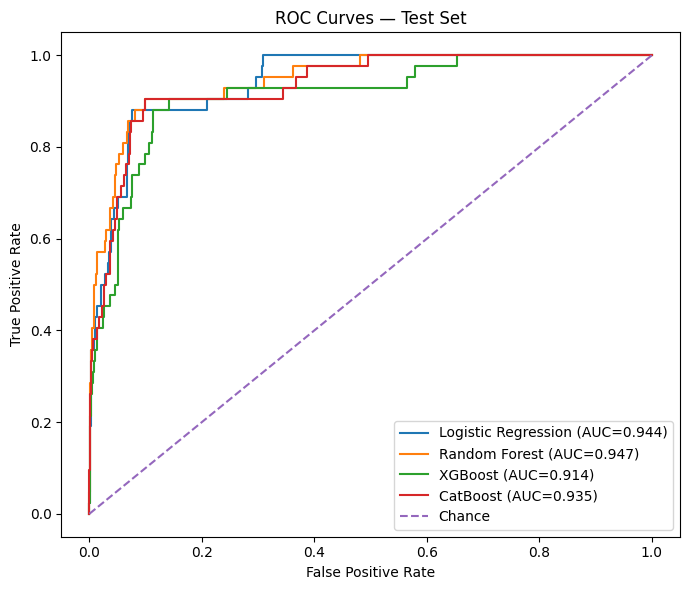

In [20]:
plt.figure(figsize=(7, 6))

for model_name, probs in test_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Test Set")
plt.legend()
plt.tight_layout()

roc_path = FIGURE_DIR / "ROC_curves_test.png"
plt.savefig(roc_path, dpi=300, bbox_inches="tight")
plt.show()


## Step 17 - Precision-Recall curve


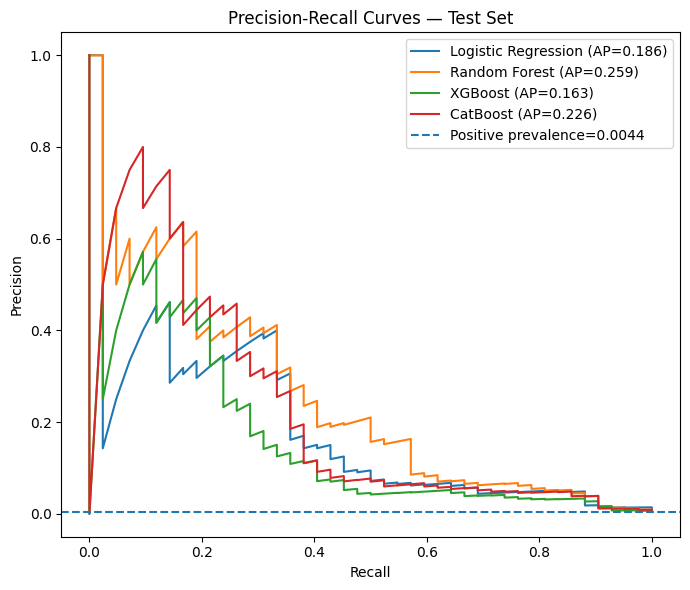

In [21]:
plt.figure(figsize=(7, 6))

for model_name, probs in test_probabilities.items():
    precision, recall, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    plt.plot(recall, precision, label=f"{model_name} (AP={ap:.3f})")

baseline = y_test.mean()
plt.axhline(baseline, linestyle="--", label=f"Positive prevalence={baseline:.4f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — Test Set")
plt.legend()
plt.tight_layout()

pr_path = FIGURE_DIR / "Precision_Recall_curves_test.png"
plt.savefig(pr_path, dpi=300, bbox_inches="tight")
plt.show()


## Step 18 - Final confusion matrix


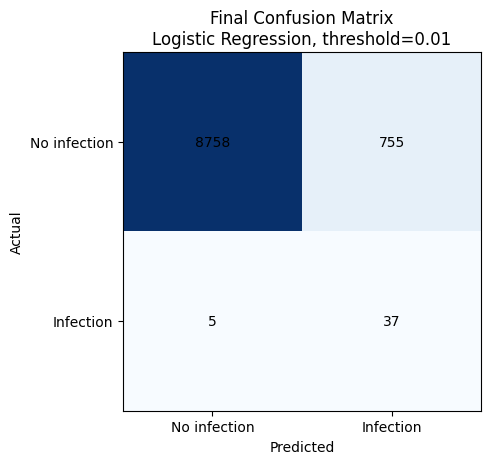

In [22]:
cm = confusion_matrix(y_test, final_test_pred, labels=[0, 1])

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap="Blues")

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["No infection", "Infection"])
ax.set_yticklabels(["No infection", "Infection"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(
    f"Final Confusion Matrix\n{selected_model_name}, threshold={CHOSEN_THRESHOLD:.2f}"
)
plt.tight_layout()

cm_path = FIGURE_DIR / "final_confusion_matrix.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()


## Step 19A - Calibration curve


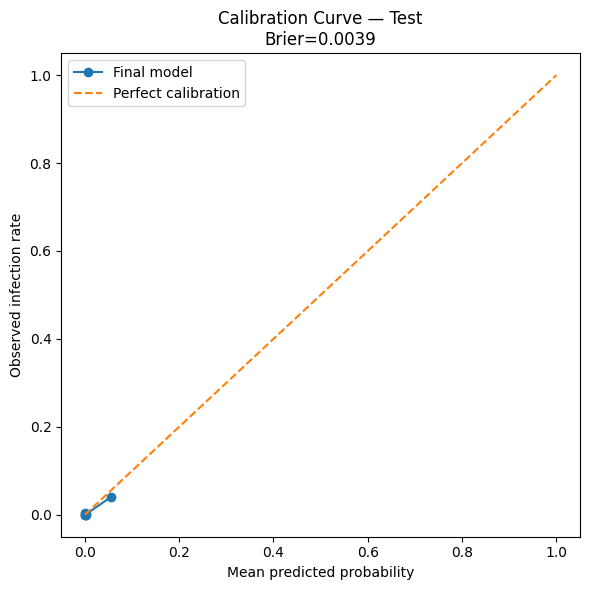

In [23]:
prob_true, prob_pred = calibration_curve(
    y_test,
    final_test_prob,
    n_bins=10,
    strategy="quantile",
)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Final model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed infection rate")
plt.title(
    f"Calibration Curve — Test\nBrier={brier_score_loss(y_test, final_test_prob):.4f}"
)
plt.legend()
plt.tight_layout()

calibration_path = FIGURE_DIR / "final_calibration_curve.png"
plt.savefig(calibration_path, dpi=300, bbox_inches="tight")
plt.show()


## Step 19B - Brier Score: Probability Reliability Verification

The **Brier Score** is used to verify whether the predicted infection probabilities are reliable as probabilities, not only whether the model discriminates between infected and non-infected patients.

It is defined as the mean squared difference between the predicted probability and the observed binary outcome.  
**Lower values are better; 0 indicates perfect probabilistic predictions.**

This verification is intentionally performed **after the calibration method and threshold have already been locked using Train/Cross-Validation**, so the Test set remains an unbiased final evaluation set.

The table below compares:
- the Dummy prevalence baseline,
- the selected model before post-hoc calibration,
- the final model after the selected calibration procedure.

This provides a direct quantitative check of whether probability calibration improved the reliability of the model's clinical risk estimates.


In [24]:
# Dedicated Brier Score verification on the locked Test set.
# This cell does not alter model selection, calibration selection, or threshold tuning.

selected_uncalibrated_test_prob = test_probabilities[selected_model_name]

brier_dummy = brier_score_loss(y_test, dummy_prob_test)
brier_uncalibrated = brier_score_loss(y_test, selected_uncalibrated_test_prob)
brier_final = brier_score_loss(y_test, final_test_prob)

brier_verification = pd.DataFrame([
    {
        "probability_source": "Dummy prevalence baseline",
        "calibration": "none",
        "Brier_Score": brier_dummy,
    },
    {
        "probability_source": f"{selected_model_name} - uncalibrated",
        "calibration": "none",
        "Brier_Score": brier_uncalibrated,
    },
    {
        "probability_source": f"{selected_model_name} - final",
        "calibration": selected_calibration_method,
        "Brier_Score": brier_final,
    },
])

brier_verification["Brier_vs_dummy_improvement"] = (
    brier_dummy - brier_verification["Brier_Score"]
)

if brier_uncalibrated > 0:
    calibration_brier_change_pct = (
        (brier_uncalibrated - brier_final) / brier_uncalibrated * 100
    )
else:
    calibration_brier_change_pct = np.nan

display(brier_verification)

print(f"Dummy Brier Score:                 {brier_dummy:.6f}")
print(f"Selected model - uncalibrated:   {brier_uncalibrated:.6f}")
print(f"Final model - {selected_calibration_method}: {brier_final:.6f}")

if selected_calibration_method == "none":
    print("Calibration result: no post-hoc calibration method improved Train/CV Brier Score enough to replace the raw probabilities.")
elif brier_final < brier_uncalibrated:
    print(f"Calibration improved Test Brier Score by {calibration_brier_change_pct:.2f}%.")
elif brier_final > brier_uncalibrated:
    print(f"Calibration increased Test Brier Score by {abs(calibration_brier_change_pct):.2f}% on the held-out Test set.")
else:
    print("Calibration produced no change in Test Brier Score.")

# Save the dedicated probability-reliability verification table.
brier_verification.to_csv(
    OUTPUT_DIR / "06b_brier_probability_verification.csv",
    index=False,
    encoding="utf-8-sig",
)


,probability_source,calibration,Brier_Score,Brier_vs_dummy_improvement
0,Dummy prevalence baseline,none,0.004433,0.000000
1,Logistic Regression - uncalibrated,none,0.048100,-0.043667
2,Logistic Regression - final,isotonic,0.003867,0.000566


Dummy Brier Score:                 0.004433
Selected model - uncalibrated:   0.048100
Final model - isotonic: 0.003867
Calibration improved Test Brier Score by 91.96%.


# Part H - Structured-only vs Structured + NLP

## Step 20 - Does NLP add predictive value?

This comparison is enabled only if model columns beginning with `nlp_` exist.

The same locked algorithm and Train-CV framework are compared:
- Structured + NLP
- Structured only

The decision about NLP contribution should be based primarily on **Train/CV consistency**, with Test shown once as final confirmation.


In [25]:
nlp_comparison = pd.DataFrame()

if RUN_NLP_COMPARISON:
    nlp_cols = [c for c in X_train.columns if c.startswith("nlp_")]

    if not nlp_cols:
        print("No model columns beginning with 'nlp_' were found. NLP comparison skipped.")
    else:
        structured_cols = [c for c in X_train.columns if c not in nlp_cols]

        comparison_rows = []

        for label, cols in {
            "Structured + NLP": list(X_train.columns),
            "Structured only": structured_cols,
        }.items():
            estimator = clone(best_estimators[selected_model_name])

            scores = cross_validate(
                estimator,
                X_train[cols],
                y_train,
                cv=cv,
                scoring={
                    "pr_auc": "average_precision",
                    "roc_auc": "roc_auc",
                    "recall": "recall",
                },
                n_jobs=N_JOBS if selected_model_name != "CatBoost" else 1,
            )

            fitted = clone(estimator)
            fitted.fit(X_train[cols], y_train)
            probs = fitted.predict_proba(X_test[cols])[:, 1]

            comparison_rows.append({
                "feature_set": label,
                "n_features": len(cols),
                "CV_PR_AUC_mean": np.mean(scores["test_pr_auc"]),
                "CV_PR_AUC_std": np.std(scores["test_pr_auc"]),
                "CV_ROC_AUC_mean": np.mean(scores["test_roc_auc"]),
                "CV_recall_mean_default_threshold": np.mean(scores["test_recall"]),
                "Test_PR_AUC": average_precision_score(y_test, probs),
                "Test_ROC_AUC": roc_auc_score(y_test, probs),
            })

        nlp_comparison = pd.DataFrame(comparison_rows)
        display(nlp_comparison)
else:
    print("Structured-vs-NLP comparison disabled.")


,feature_set,n_features,CV_PR_AUC_mean,CV_PR_AUC_std,CV_ROC_AUC_mean,CV_recall_mean_default_threshold,Test_PR_AUC,Test_ROC_AUC
0,Structured + NLP,20,0.328573,0.035408,0.920981,0.868947,0.186252,0.943558
1,Structured only,19,0.316179,0.035185,0.916474,0.858947,0.190009,0.948744


# Part I - Explainability

## Step 21 - Permutation importance

Permutation Importance is calculated on Test for **descriptive explanation only**, after all model-selection decisions are locked.

It must not be used to go back and change the model based on Test.


In [26]:
# Explain the underlying selected uncalibrated estimator.
explain_model = fitted_models[selected_model_name]

perm = permutation_importance(
    explain_model,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS if selected_model_name != "CatBoost" else 1,
)

permutation_importance_results = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

display(permutation_importance_results.head(30))


,feature,importance_mean,importance_std
0,detected_pathogen_Other,0.133042,0.016043
1,detected_pathogen_Unknown,0.101490,0.009997
2,procedure_icd9_1,0.009381,0.011380
3,age,0.006067,0.004583
4,nlp_tfidf_logreg_risk_score,0.004429,0.010422
5,procedure_1_Other,0.000000,0.000000
6,recovery_duration_minutes,0.000000,0.000000
7,recovery_bed___MISSING__,0.000000,0.000000
8,added1_detected_pathogen_specimen_source_Unknown,0.000000,0.000000
9,added1_detected_pathogen_specimen_source_Other,0.000000,0.000000


## Step 22 - Logistic Regression coefficients / odds ratios

If Logistic Regression is available, coefficients are reported as a transparent benchmark even when it is not the final selected model.


In [27]:
logistic_explainability = pd.DataFrame()

if "Logistic Regression" in fitted_models:
    lr_fitted = fitted_models["Logistic Regression"]
    if isinstance(lr_fitted, ResampledClassifier):
        lr_pipeline = lr_fitted.estimator_
    else:
        lr_pipeline = lr_fitted

    if hasattr(lr_pipeline,"named_steps"):
        lr_model = lr_pipeline.named_steps["model"]
    else: lr_model = lr_pipeline

    logistic_explainability = pd.DataFrame({
        "feature": X_train.columns,
        "coefficient": lr_model.coef_[0],
        "odds_ratio": np.exp(lr_model.coef_[0]),
        "abs_coefficient": np.abs(lr_model.coef_[0]),
    }).sort_values("abs_coefficient", ascending=False)

    display(logistic_explainability.head(30))


,feature,coefficient,odds_ratio,abs_coefficient
1,detected_pathogen_Other,1.123899,3.076828,1.123899
2,surgeon_specialization_כיר' בית חזה,0.840089,2.316574,0.840089
0,detected_pathogen_Unknown,-0.683679,0.504756,0.683679
3,added1_mrsa_result_Unknown,-0.474778,0.622023,0.474778
10,activity_cluster_כירורגיה כללית,-0.411802,0.662456,0.411802
18,has_catheter,0.244632,1.277151,0.244632
13,procedure_icd9_1,-0.116266,0.890238,0.116266
9,nlp_tfidf_logreg_risk_score,0.084769,1.088465,0.084769
19,age,0.052482,1.053883,0.052482
8,surgery_bed_number,-0.041023,0.959807,0.041023


## Step 23 - SHAP for the locked final algorithm

SHAP is optional because package support differs by environment.

For computational safety, a sample of Test rows is used.


,feature,mean_abs_SHAP
0,activity_cluster_כירורגיה כללית,0.438888
1,surgeon_specialization_כיר' בית חזה,0.338106
2,added1_mrsa_result_Unknown,0.187354
3,has_catheter,0.146381
4,procedure_icd9_1,0.084795
5,nlp_tfidf_logreg_risk_score,0.052729
6,age,0.049754
7,surgery_bed_number,0.048147
8,detected_pathogen_Unknown,0.012036
9,detected_pathogen_Other,0.006595


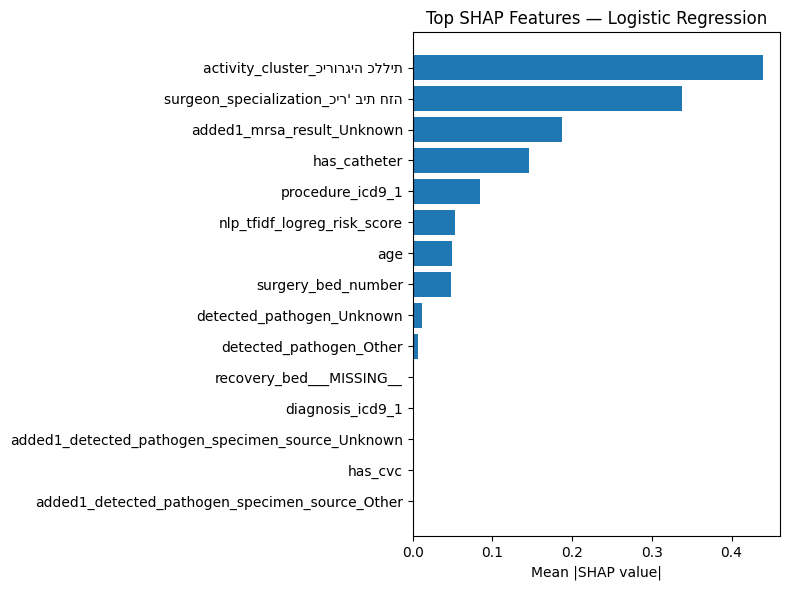

In [28]:
shap_importance = pd.DataFrame()

if RUN_SHAP and HAS_SHAP:
    try:
        sample_n = min(500, len(X_test))
        X_shap = X_test.sample(sample_n, random_state=RANDOM_STATE)

        base_model = fitted_models[selected_model_name]

        #Unwrap the fitted estimator when a resampling wrapper was used
        if isinstance(base_model, ResampledClassifier):
            base_model = base_model.estimator_ 

        if selected_model_name == "Logistic Regression":
            scaler = base_model.named_steps["scaler"]
            lr = base_model.named_steps["model"]
            X_scaled = scaler.transform(X_shap)

            explainer = shap.LinearExplainer(
                lr,
                scaler.transform(X_train.sample(min(1000, len(X_train)), random_state=RANDOM_STATE)),
            )
            shap_values = explainer(X_scaled)
            values = np.abs(shap_values.values).mean(axis=0)

        else:
            explainer = shap.Explainer(base_model, X_train.sample(
                min(500, len(X_train)),
                random_state=RANDOM_STATE,
            ))
            shap_values = explainer(X_shap)
            values_array = shap_values.values

            if values_array.ndim == 3:
                values_array = values_array[:, :, -1]

            values = np.abs(values_array).mean(axis=0)

        shap_importance = (
            pd.DataFrame({
                "feature": X_train.columns,
                "mean_abs_SHAP": values,
            })
            .sort_values("mean_abs_SHAP", ascending=False)
            .reset_index(drop=True)
        )

        display(shap_importance.head(30))

        plt.figure(figsize=(8, 6))
        top = shap_importance.head(15).sort_values("mean_abs_SHAP")
        plt.barh(top["feature"], top["mean_abs_SHAP"])
        plt.xlabel("Mean |SHAP value|")
        plt.title(f"Top SHAP Features — {selected_model_name}")
        plt.tight_layout()

        shap_path = FIGURE_DIR / "final_model_SHAP_top_features.png"
        plt.savefig(shap_path, dpi=300, bbox_inches="tight")
        plt.show()

    except Exception as exc:
        print("SHAP could not be completed in this environment:", exc)
else:
    print("SHAP disabled or package unavailable.")


# Part J - Error analysis

## Step 24 - False Negatives and False Positives

These tables are keyed by `case_number` so the clinical team can review the specific surgeries the model missed or over-alerted.


In [29]:
test_predictions = pd.DataFrame({
    CASE_ID_COL: test_case_ids.values,
    "y_true": y_test.values,
    "predicted_probability": final_test_prob,
    "predicted_class": final_test_pred,
})

test_predictions["error_type"] = "correct"
test_predictions.loc[
    (test_predictions["y_true"] == 1)
    & (test_predictions["predicted_class"] == 0),
    "error_type"
] = "False Negative"

test_predictions.loc[
    (test_predictions["y_true"] == 0)
    & (test_predictions["predicted_class"] == 1),
    "error_type"
] = "False Positive"

false_negatives = test_predictions[
    test_predictions["error_type"] == "False Negative"
].sort_values("predicted_probability")

false_positives = test_predictions[
    test_predictions["error_type"] == "False Positive"
].sort_values("predicted_probability", ascending=False)

print(f"False Negatives: {len(false_negatives)}")
print(f"False Positives: {len(false_positives)}")

display(false_negatives.head(20))
display(false_positives.head(20))


False Negatives: 5
False Positives: 755


,case_number,y_true,predicted_probability,predicted_class,error_type
3102,20785742,1,0.000866,0,False Negative
3331,20789092,1,0.000866,0,False Negative
694,20747423,1,0.001080,0,False Negative
4106,20801752,1,0.001080,0,False Negative
5875,20830460,1,0.001946,0,False Negative


,case_number,y_true,predicted_probability,predicted_class,error_type
697,20747488,0,0.613889,1,False Positive
630,20746426,0,0.613889,1,False Positive
6157,20834945,0,0.613889,1,False Positive
1144,20754317,0,0.613889,1,False Positive
7261,20852258,0,0.613889,1,False Positive
7821,20860933,0,0.613889,1,False Positive
3779,20796622,0,0.613889,1,False Positive
3308,20788775,0,0.613889,1,False Positive
5510,20824050,0,0.613889,1,False Positive
5656,20826814,0,0.613889,1,False Positive


## Step 25 - Subgroup analysis

If the original final feature table is available, this section joins Test predictions back to clinically interpretable columns by `case_number`.

It reports subgroup metrics only for columns that actually exist.

This is descriptive final evaluation and must not be used to re-select the model.


In [30]:
subgroup_results = pd.DataFrame()

if RUN_SUBGROUP_ANALYSIS and STEP5_FINAL_FEATURE_TABLE_PATH.exists():
    feature_reference = pd.read_csv(
        STEP5_FINAL_FEATURE_TABLE_PATH,
        encoding="utf-8-sig",
    )

    if CASE_ID_COL not in feature_reference.columns:
        print("Step 5 reference table has no case_number; subgroup analysis skipped.")
    else:
        test_context = test_predictions.merge(
            feature_reference,
            on=CASE_ID_COL,
            how="left",
            validate="one_to_one",
        )

        available_subgroups = [
            c for c in SUBGROUP_COLUMNS
            if c in test_context.columns
        ]

        rows = []

        for col in available_subgroups:
            for group_value, group in test_context.groupby(col, dropna=False):
                if len(group) < 20:
                    continue

                y_g = group["y_true"].astype(int)
                p_g = group["predicted_probability"]
                pred_g = group["predicted_class"].astype(int)

                if y_g.nunique() < 2:
                    pr_auc = np.nan
                    roc_auc = np.nan
                else:
                    pr_auc = average_precision_score(y_g, p_g)
                    roc_auc = roc_auc_score(y_g, p_g)

                rows.append({
                    "subgroup_variable": col,
                    "group": str(group_value),
                    "n": len(group),
                    "positives": int(y_g.sum()),
                    "PR_AUC": pr_auc,
                    "ROC_AUC": roc_auc,
                    "recall": recall_score(y_g, pred_g, zero_division=0),
                    "precision": precision_score(y_g, pred_g, zero_division=0),
                })

        subgroup_results = pd.DataFrame(rows)

        if not subgroup_results.empty:
            display(subgroup_results)
        else:
            print("No subgroup table met the minimum-size criteria.")
else:
    print("Subgroup analysis disabled or Step 5 reference table unavailable.")


,subgroup_variable,group,n,positives,PR_AUC,ROC_AUC,recall,precision
0,department,חדר ניתוח,9475,40,0.199208,0.945262,0.875000,0.048011
1,department,צינתורים,61,2,0.026667,0.199153,1.000000,0.033333
2,high_asa,0.0,6593,19,0.302447,0.943654,0.789474,0.103448
3,high_asa,1.0,1733,21,0.112882,0.849285,0.952381,0.031797
4,high_asa,nan,1229,2,0.088889,0.990424,1.000000,0.111111
5,bmi_category,normal,2565,3,0.081737,0.976776,1.000000,0.016393
6,bmi_category,obesity,2007,12,0.178338,0.947682,0.916667,0.061111
7,bmi_category,overweight,2805,17,0.318963,0.937315,0.882353,0.053763
8,bmi_category,underweight,99,0,NaN,NaN,0.000000,0.000000
9,bmi_category,nan,2079,10,0.154145,0.922015,0.800000,0.055172


# Part L - Save all final outputs

## Step 27 - Tables, predictions and model metadata


In [31]:
# Main tables
cv_results.to_csv(
    OUTPUT_DIR / "01_cross_validation_results.csv",
    index=False,
    encoding="utf-8-sig",
)

if not balancing_screen_results.empty:
    balancing_screen_results.to_csv(
        OUTPUT_DIR / "02_balancing_strategy_screen.csv",
        index=False,
        encoding="utf-8-sig",
    )

balancing_strategy_summary.to_csv(
    OUTPUT_DIR / "02b_balancing_strategy_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

tuning_results.to_csv(
    OUTPUT_DIR / "03_hyperparameter_tuning_results.csv",
    index=False,
    encoding="utf-8-sig",
)

threshold_review.to_csv(
    OUTPUT_DIR / "04_threshold_review_train_oof.csv",
    index=False,
    encoding="utf-8-sig",
)

calibration_selection.to_csv(
    OUTPUT_DIR / "05_calibration_selection_train_cv.csv",
    index=False,
    encoding="utf-8-sig",
)

calibration_audit.to_csv(
    OUTPUT_DIR / "05b_calibration_audit.csv",
    index=False,
    encoding="utf-8-sig",
)

test_metrics.to_csv(
    OUTPUT_DIR / "06_final_test_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

test_predictions.to_csv(
    OUTPUT_DIR / "07_test_predictions_and_errors.csv",
    index=False,
    encoding="utf-8-sig",
)

false_negatives.to_csv(
    OUTPUT_DIR / "08_false_negatives.csv",
    index=False,
    encoding="utf-8-sig",
)

false_positives.to_csv(
    OUTPUT_DIR / "09_false_positives.csv",
    index=False,
    encoding="utf-8-sig",
)

permutation_importance_results.to_csv(
    OUTPUT_DIR / "10_permutation_importance.csv",
    index=False,
    encoding="utf-8-sig",
)

if not logistic_explainability.empty:
    logistic_explainability.to_csv(
        OUTPUT_DIR / "11_logistic_coefficients_odds_ratios.csv",
        index=False,
        encoding="utf-8-sig",
    )

if not shap_importance.empty:
    shap_importance.to_csv(
        OUTPUT_DIR / "12_shap_importance.csv",
        index=False,
        encoding="utf-8-sig",
    )

if not subgroup_results.empty:
    subgroup_results.to_csv(
        OUTPUT_DIR / "13_subgroup_analysis.csv",
        index=False,
        encoding="utf-8-sig",
    )

if not nlp_comparison.empty:
    nlp_comparison.to_csv(
        OUTPUT_DIR / "14_structured_vs_nlp_comparison.csv",
        index=False,
        encoding="utf-8-sig",
    )


# Model-selection metadata
metadata = {
    "selected_balancing_strategy": SELECTED_BALANCING_STRATEGY,
    "selected_model_name": selected_model_name,
    "selection_basis": "balancing strategy screened first; final model selected by highest Train/CV Average Precision (PR-AUC)",
    "selected_calibration_method": selected_calibration_method,
    "chosen_threshold": CHOSEN_THRESHOLD,
    "threshold_reason": threshold_reason,
    "clinical_nns_target": CLINICAL_NNS_TARGET,
    "clinical_recall_target": CLINICAL_RECALL_TARGET,
    "ctgan_auto_selection_allowed": ALLOW_CTGAN_AUTO_SELECTION,
    "random_state": RANDOM_STATE,
    "cv_folds": CV_FOLDS,
    "n_train": len(X_train),
    "n_test": len(X_test),
    "n_features": X_train.shape[1],
}

with open(
    MODEL_DIR / "final_model_metadata.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f"All Step 7 outputs saved to: {OUTPUT_DIR}")


All Step 7 outputs saved to: H:\27 project\models\step7_outputs


## Step 28 - Final project summary table


In [32]:
final_summary = pd.DataFrame([{
    "Balancing strategy": SELECTED_BALANCING_STRATEGY,
    "Final algorithm locked from Train/CV": selected_model_name,
    "Calibration": selected_calibration_method,
    "Threshold": CHOSEN_THRESHOLD,
    "Threshold rule": threshold_reason,
    "Test PR-AUC": average_precision_score(y_test, final_test_prob),
    "Test ROC-AUC": roc_auc_score(y_test, final_test_prob),
    "Test Recall": recall_score(y_test, final_test_pred, zero_division=0),
    "Test Precision": precision_score(y_test, final_test_pred, zero_division=0),
    "Test F1": f1_score(y_test, final_test_pred, zero_division=0),
    "Test F2": fbeta_score(y_test, final_test_pred, beta=2, zero_division=0),
    "Test Brier": brier_score_loss(y_test, final_test_prob),
    "False Negatives": int(((y_test.values == 1) & (final_test_pred == 0)).sum()),
    "False Positives": int(((y_test.values == 0) & (final_test_pred == 1)).sum()),
}])

display(final_summary)

final_summary.to_csv(
    OUTPUT_DIR / "FINAL_PROJECT_MODEL_SUMMARY.csv",
    index=False,
    encoding="utf-8-sig",
)


,Balancing strategy,Final algorithm locked from Train/CV,Calibration,Threshold,Threshold rule,Test PR-AUC,Test ROC-AUC,Test Recall,Test Precision,Test F1,Test F2,Test Brier,False Negatives,False Positives
0,smote,Logistic Regression,isotonic,0.01,maximum calibrated (isotonic) OOF recall among...,0.182666,0.942716,0.880952,0.046717,0.088729,0.192708,0.003867,5,755


## Step 29 - Final validation gate

If this gate passes, the modeling notebook has completed the planned technical outputs.


In [33]:
print("=" * 76)
print("STEP 7 - FINAL VALIDATION GATE")
print("=" * 76)

checks = {
    "Four project algorithms available or explicitly reported unavailable":
        {"Logistic Regression", "Random Forest"}.issubset(model_candidates.keys()),

    "Prototype-only baseline available":
        "prototype_only" in available_strategies,

    "Balancing strategy selected from Train/CV":
        SELECTED_BALANCING_STRATEGY in available_strategies,

    "Final algorithm selected from Train/CV":
        selected_model_name in best_estimators,

    "Chosen threshold is valid":
        0 < CHOSEN_THRESHOLD < 1,

    "Final Test probabilities complete":
        len(final_test_prob) == len(y_test) and np.isfinite(final_test_prob).all(),

    "Final Test predictions complete":
        len(final_test_pred) == len(y_test),

    "No Test rows lost":
        len(test_predictions) == len(X_test),

    "Final summary generated":
        len(final_summary) == 1,
}


# If the clinical NNS criterion is active, the final locked threshold must still
# satisfy it on the OOF probabilities used for threshold selection.
if CLINICAL_NNS_TARGET is not None:
    final_locked_nns = float(chosen_threshold_row["NNS"])
    checks["Locked OOF threshold satisfies clinical NNS target"] = (
        np.isfinite(final_locked_nns)
        and final_locked_nns <= CLINICAL_NNS_TARGET
    )


all_ok = True

for label, passed in checks.items():
    status = "OK" if passed else "FAIL"
    print(f"{status}: {label}")
    all_ok = all_ok and bool(passed)

print()
if all_ok:
    print("STEP 7 TECHNICAL PIPELINE COMPLETE.")
    print("Review the saved model comparison, threshold, calibration, error and explainability outputs before writing conclusions.")
else:
    print("STEP 7 NOT COMPLETE - review FAIL item(s) above.")


STEP 7 - FINAL VALIDATION GATE
OK: Four project algorithms available or explicitly reported unavailable
OK: Prototype-only baseline available
OK: Balancing strategy selected from Train/CV
OK: Final algorithm selected from Train/CV
OK: Chosen threshold is valid
OK: Final Test probabilities complete
OK: Final Test predictions complete
OK: No Test rows lost
OK: Final summary generated
OK: Locked OOF threshold satisfies clinical NNS target

STEP 7 TECHNICAL PIPELINE COMPLETE.
Review the saved model comparison, threshold, calibration, error and explainability outputs before writing conclusions.
